# 🔹  Carregamento dos Dados

In [25]:
import pandas as pd

# Carregando os dados do arquivo CSV usando o caminho correto
df_novo = pd.read_csv('/content/dados_tratados.csv')

# Verificando os dados
print(df_novo.head())

   ID_Cliente Churn  Genero  Idoso Tem_Parceiro Dependentes  Tempo_Contrato  \
0  0002-ORFBO    No  Female      0          Yes         Yes               9   
1  0003-MKNFE    No    Male      0           No          No               9   
2  0004-TLHLJ   Yes    Male      0           No          No               4   
3  0011-IGKFF   Yes    Male      1          Yes          No              13   
4  0013-EXCHZ   Yes  Female      1          Yes          No               3   

  Telefone_Servico Linhas_Multiples Internet_Servico  ... Suporte_Tecnico  \
0              Yes               No              DSL  ...             Yes   
1              Yes              Yes              DSL  ...              No   
2              Yes               No      Fiber optic  ...              No   
3              Yes               No      Fiber optic  ...              No   
4              Yes               No      Fiber optic  ...             Yes   

  Streaming_TV Streaming_Filmes        Contrato Faturamento_Se

In [26]:
df_novo = pd.read_csv("dados_tratados.csv")

In [27]:
df_novo

,ID_Cliente,Churn,Genero,Idoso,Tem_Parceiro,Dependentes,Tempo_Contrato,Telefone_Servico,Linhas_Multiples,Internet_Servico,...,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Contrato,Faturamento_Sem_Papel,Metodo_Pagamento,Faturamento_Mensal,Faturamento_Total,Cancelou,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3,0.0,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4,0.0,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85,1.0,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85,1.0,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4,1.0,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,Yes,No,No,One year,No,Mailed check,55.15,742.9,0.0,1.838333
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7,1.0,2.836667
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75,0.0,1.676667
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65,0.0,2.261667


# 🔹1️⃣ Remoção de Colunas Irrelevantes

In [28]:
# Verificando colunas
print(df_novo.columns)

# Removendo ID e Cancelou
df_novo = df_novo.drop(columns=['ID_Cliente', 'Cancelou'])

df_novo.head()

Index(['ID_Cliente', 'Churn', 'Genero', 'Idoso', 'Tem_Parceiro', 'Dependentes',
       'Tempo_Contrato', 'Telefone_Servico', 'Linhas_Multiples',
       'Internet_Servico', 'Seguranca_Online', 'Backup_Online',
       'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV',
       'Streaming_Filmes', 'Contrato', 'Faturamento_Sem_Papel',
       'Metodo_Pagamento', 'Faturamento_Mensal', 'Faturamento_Total',
       'Cancelou', 'Contas_Diarias'],
      dtype='object')


,Churn,Genero,Idoso,Tem_Parceiro,Dependentes,Tempo_Contrato,Telefone_Servico,Linhas_Multiples,Internet_Servico,Seguranca_Online,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Contrato,Faturamento_Sem_Papel,Metodo_Pagamento,Faturamento_Mensal,Faturamento_Total,Contas_Diarias
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667


# 🔹 2️⃣ Separar Variável Alvo (Churn) e Variáveis Independentes

In [29]:
# Convertendo Churn para binário
df_novo['Churn'] = df_novo['Churn'].map({'No': 0, 'Yes': 1})

df_novo['Churn'].value_counts()

,count
Churn,
0.0,5174
1.0,1869


# 🔹 3️⃣ Separar X e y

In [30]:
X = df_novo.drop('Churn', axis=1)
y = df_novo['Churn']

# 🔹 4️⃣ One-Hot Encoding nas Variáveis Categóricas

In [31]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Idoso,Tempo_Contrato,Faturamento_Mensal,Contas_Diarias,Genero_Male,Tem_Parceiro_Yes,Dependentes_Yes,Telefone_Servico_Yes,Linhas_Multiples_No phone service,Linhas_Multiples_Yes,...,Faturamento_Total_995.35,Faturamento_Total_996.45,Faturamento_Total_996.85,Faturamento_Total_996.95,Faturamento_Total_997.65,Faturamento_Total_997.75,Faturamento_Total_998.1,Faturamento_Total_999.45,Faturamento_Total_999.8,Faturamento_Total_999.9
0,0,9,65.6,2.186667,False,True,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,9,59.9,1.996667,True,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,0,4,73.9,2.463333,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,13,98.0,3.266667,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,3,83.9,2.796667,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


# 🔹 5️⃣ Verificar Desbalanceamento

In [32]:
print("Proporção das classes:")
print(y.value_counts(normalize=True))

Proporção das classes:
Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64


# 🔹 6️⃣ Divisão Treino/Teste (Estratificada)

In [33]:
# Removendo valores NaN de y e X
non_nan_indices = y.dropna().index
X = X.loc[non_nan_indices]
y = y.loc[non_nan_indices]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 🔹 7️⃣ Padronização (para Regressão Logística)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 8️⃣ Modelo 1 – Regressão Logística

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train_scaled, y_train)

y_pred_lr = modelo_lr.predict(X_test_scaled)

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nRelatório:")
print(classification_report(y_test, y_pred_lr))

print("\nROC-AUC:",
      roc_auc_score(y_test, modelo_lr.predict_proba(X_test_scaled)[:,1]))

Matriz de Confusão:
[[1387  165]
 [ 316  245]]

Relatório:
              precision    recall  f1-score   support

         0.0       0.81      0.89      0.85      1552
         1.0       0.60      0.44      0.50       561

    accuracy                           0.77      2113
   macro avg       0.71      0.67      0.68      2113
weighted avg       0.76      0.77      0.76      2113


ROC-AUC: 0.8040209171766176


# 🔹 9️⃣ Modelo 2 – Random Forest

In [36]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_test)

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRelatório:")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC:",
      roc_auc_score(y_test, modelo_rf.predict_proba(X_test)[:,1]))

Matriz de Confusão:
[[1404  148]
 [ 303  258]]

Relatório:
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      1552
         1.0       0.64      0.46      0.53       561

    accuracy                           0.79      2113
   macro avg       0.73      0.68      0.70      2113
weighted avg       0.77      0.79      0.77      2113


ROC-AUC: 0.8216733741294081


# 🔹 🔟 Importância das Variáveis

Tempo_Contrato                       0.109908
Contas_Diarias                       0.078816
Faturamento_Mensal                   0.078753
Metodo_Pagamento_Electronic check    0.031138
Internet_Servico_Fiber optic         0.025036
Contrato_Two year                    0.023606
Suporte_Tecnico_Yes                  0.022179
Contrato_One year                    0.021375
Faturamento_Sem_Papel_Yes            0.020263
Seguranca_Online_Yes                 0.020095
dtype: float64


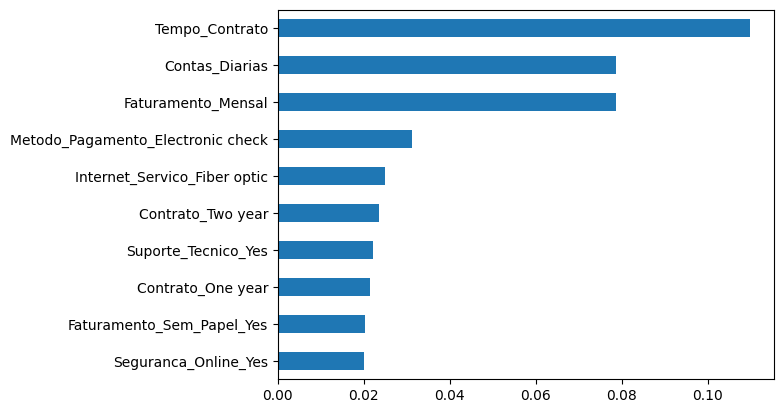

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias.head(10))

importancias.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.show()

# 🔹 1️⃣1️⃣ Matriz de Correlação (Numéricas)

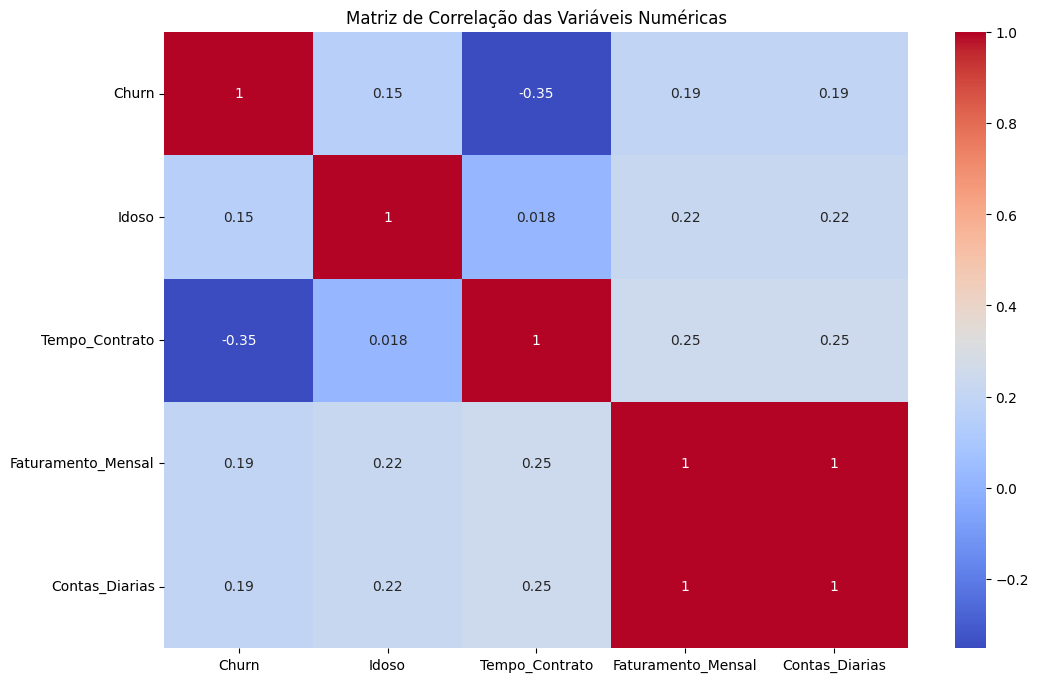

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas variáveis numéricas
num_vars = df_novo.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12,8))
sns.heatmap(df_novo[num_vars].corr(), annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

# 🔹1️⃣ 2️⃣ Análise Direcionada — Tempo de Contrato × Churn

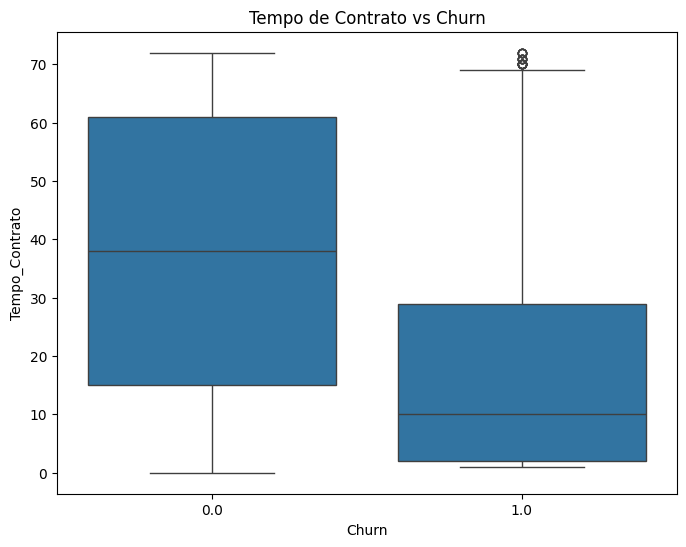

In [39]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='Tempo_Contrato', data=df_novo)
plt.title("Tempo de Contrato vs Churn")
plt.show()

# 🔹1️⃣ 3️⃣ Análise Direcionada — Faturamento Total × Churn

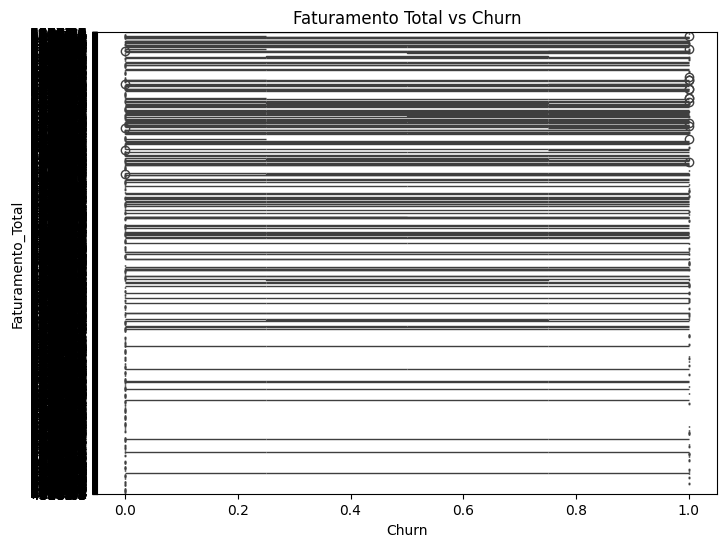

In [24]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Churn', y='Faturamento_Total', data=df_novo)
plt.title("Faturamento Total vs Churn")
plt.show()

# 🔹1️⃣ 4️⃣ Dispersão (Scatter) — Faturamento Mensal × Total Gasto

In [39]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Faturamento_Mensal',
    y='Faturamento_Total',
    hue='Churn',
    alpha=0.7,
    data=df_novo
)
plt.title("Faturamento Mensal vs Faturamento Total")
plt.show()

# 🔹1️⃣ 5️⃣ Preparação de Dados — Separação em X e y

In [41]:
# Variáveis alvo e preditoras
X = df_novo.drop('Churn', axis=1)
y = df_novo['Churn']

# One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Removendo valores NaN de y e X (garantindo que y não tenha NaNs para estratificação)
non_nan_indices = y.dropna().index
X = X.loc[non_nan_indices]
y = y.loc[non_nan_indices]

# Divisão treino/teste estratificada
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (4930, 6560)
Teste: (2113, 6560)


 # 🔹1️⃣ 6️⃣ Padronização para Modelos Lineares


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🤖 Modelagem Preditiva

# 🔹 1️⃣ Separação dos Dados (Train/Test)

In [43]:
from sklearn.model_selection import train_test_split

# X e y já estão preparados, inclusive com encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 70% treino, 30% teste
    random_state=42,
    stratify=y           # Mantém proporção de churn
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (4930, 6560)
Teste: (2113, 6560)


# 🔹 2️⃣ Padronização (necessária para Regressão Logística)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Normalização apenas para modelos sensíveis à escala
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔹 3️⃣ Modelo 1 — Regressão Logística (normalização aplicada)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Criação do modelo
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train_scaled, y_train)

# Previsão
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_prob_lr = modelo_lr.predict_proba(X_test_scaled)[:,1]

# Avaliação
print("=== REGRESSÃO LOGÍSTICA ===")
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

=== REGRESSÃO LOGÍSTICA ===
Matriz de Confusão:
[[1387  165]
 [ 316  245]]

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.81      0.89      0.85      1552
         1.0       0.60      0.44      0.50       561

    accuracy                           0.77      2113
   macro avg       0.71      0.67      0.68      2113
weighted avg       0.76      0.77      0.76      2113

ROC-AUC: 0.8040209171766176


# 🔹 4️⃣ Modelo 2 — Random Forest (sem normalização)

In [46]:
from sklearn.ensemble import RandomForestClassifier

# Criação do modelo
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

# Previsão
y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:,1]

# Avaliação
print("=== RANDOM FOREST ===")
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

=== RANDOM FOREST ===
Matriz de Confusão:
[[1404  148]
 [ 303  258]]

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      1552
         1.0       0.64      0.46      0.53       561

    accuracy                           0.79      2113
   macro avg       0.73      0.68      0.70      2113
weighted avg       0.77      0.79      0.77      2113

ROC-AUC: 0.8216733741294081


# 🔹 5️⃣ Comparação Formal dos Modelos

In [47]:
roc_lr = roc_auc_score(y_test, y_prob_lr)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("=== COMPARAÇÃO ===")
print(f"ROC-AUC Regressão Logística: {roc_lr:.4f}")
print(f"ROC-AUC Random Forest: {roc_rf:.4f}")

=== COMPARAÇÃO ===
ROC-AUC Regressão Logística: 0.8040
ROC-AUC Random Forest: 0.8217


# 🔹 6️⃣ Importância das Variáveis — Random Forest

Top 10 variáveis mais importantes:
Tempo_Contrato                       0.109908
Contas_Diarias                       0.078816
Faturamento_Mensal                   0.078753
Metodo_Pagamento_Electronic check    0.031138
Internet_Servico_Fiber optic         0.025036
Contrato_Two year                    0.023606
Suporte_Tecnico_Yes                  0.022179
Contrato_One year                    0.021375
Faturamento_Sem_Papel_Yes            0.020263
Seguranca_Online_Yes                 0.020095
dtype: float64


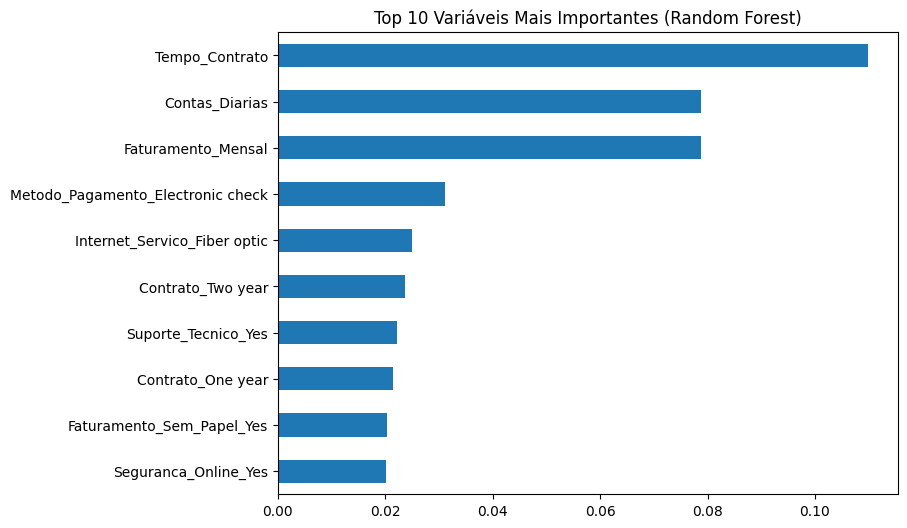

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 10 variáveis mais importantes:")
print(importancias.head(10))

plt.figure(figsize=(8,6))
importancias.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Variáveis Mais Importantes (Random Forest)")
plt.show()

# 🔹 7️⃣ Coeficientes — Regressão Logística

In [49]:
coeficientes = pd.Series(modelo_lr.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

print("Top 10 variáveis que mais impactam Churn (LR):")
print(coeficientes.head(10))

Top 10 variáveis que mais impactam Churn (LR):
Tempo_Contrato                             -1.083991
Metodo_Pagamento_Electronic check           0.977958
Backup_Online_Yes                          -0.878682
Contrato_One year                          -0.823368
Contrato_Two year                          -0.787069
Streaming_Filmes_Yes                        0.698630
Metodo_Pagamento_Mailed check               0.615053
Faturamento_Sem_Papel_Yes                   0.548279
Metodo_Pagamento_Credit card (automatic)    0.521862
Seguranca_Online_Yes                       -0.494713
dtype: float64


# 🔹 8️⃣ Insights Estratégicos Baseados nos Modelos

- Tempo de Contrato: clientes recentes têm maior risco de churn
- Faturamento Mensal / Total: clientes com valores mais altos ou inconsistentes podem churnar mais
- Tipo de Contrato (Mensal vs Anual): contratos longos reduzem churn
- Suporte Técnico: ter suporte reduz evasão
- Metodo_Pagamento_Electronic check: clientes que usam esse método apresentam mais churn

# 🔹 9️⃣ Conclusão e Estratégias

1. Retenção focada em clientes de menor tempo de contrato
2. Incentivo à migração para contratos anuais
3. Monitoramento de clientes com altos gastos mensais
4. Oferta de suporte técnico e benefícios extras
5. Análise contínua dos métodos de pagamento e comportamento financeiro

# 💾 Salvando

In [52]:
import nbformat as nbf
from google.colab import drive

# Montar Drive
drive.mount('/content/drive')

# Criar novo notebook
nb = nbf.v4.new_notebook()

# Exemplo: adicionar célula de código inicial (você pode substituir pelo seu código completo)
nb['cells'] = [nbf.v4.new_markdown_cell("# Telecom X — Parte 2: Modelagem Preditiva Churn")]

# Salvar notebook no Drive com o nome solicitado
notebook_path = '/content/drive/MyDrive/TelecomX_parte2_BR_Challenge.ipynb'
with open(notebook_path, 'w') as f:
    nbf.write(nb, f)

print(f"Notebook salvo em: {notebook_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Notebook salvo em: /content/drive/MyDrive/TelecomX_parte2_BR_Challenge.ipynb
